# Dataset Description
## Per capita income. Urban vs. Rural areas

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/pobreza-y-condiciones-de-vida/pobreza-monetaria)

# Code
## Imports

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
import matplotlib.ticker as mtick

BASE_DIR = Path.cwd().parent.parent

## Load data

In [64]:
path = "./data/ingreso_percapita.csv"
logo_path = BASE_DIR / "logo/logo.png"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,2,3])
logo = plt.imread(logo_path)

## Clean data

In [65]:
df["Diferencia"] = df["Cabeceras"] - df["Centros poblados y rural disperso"]

## Plot

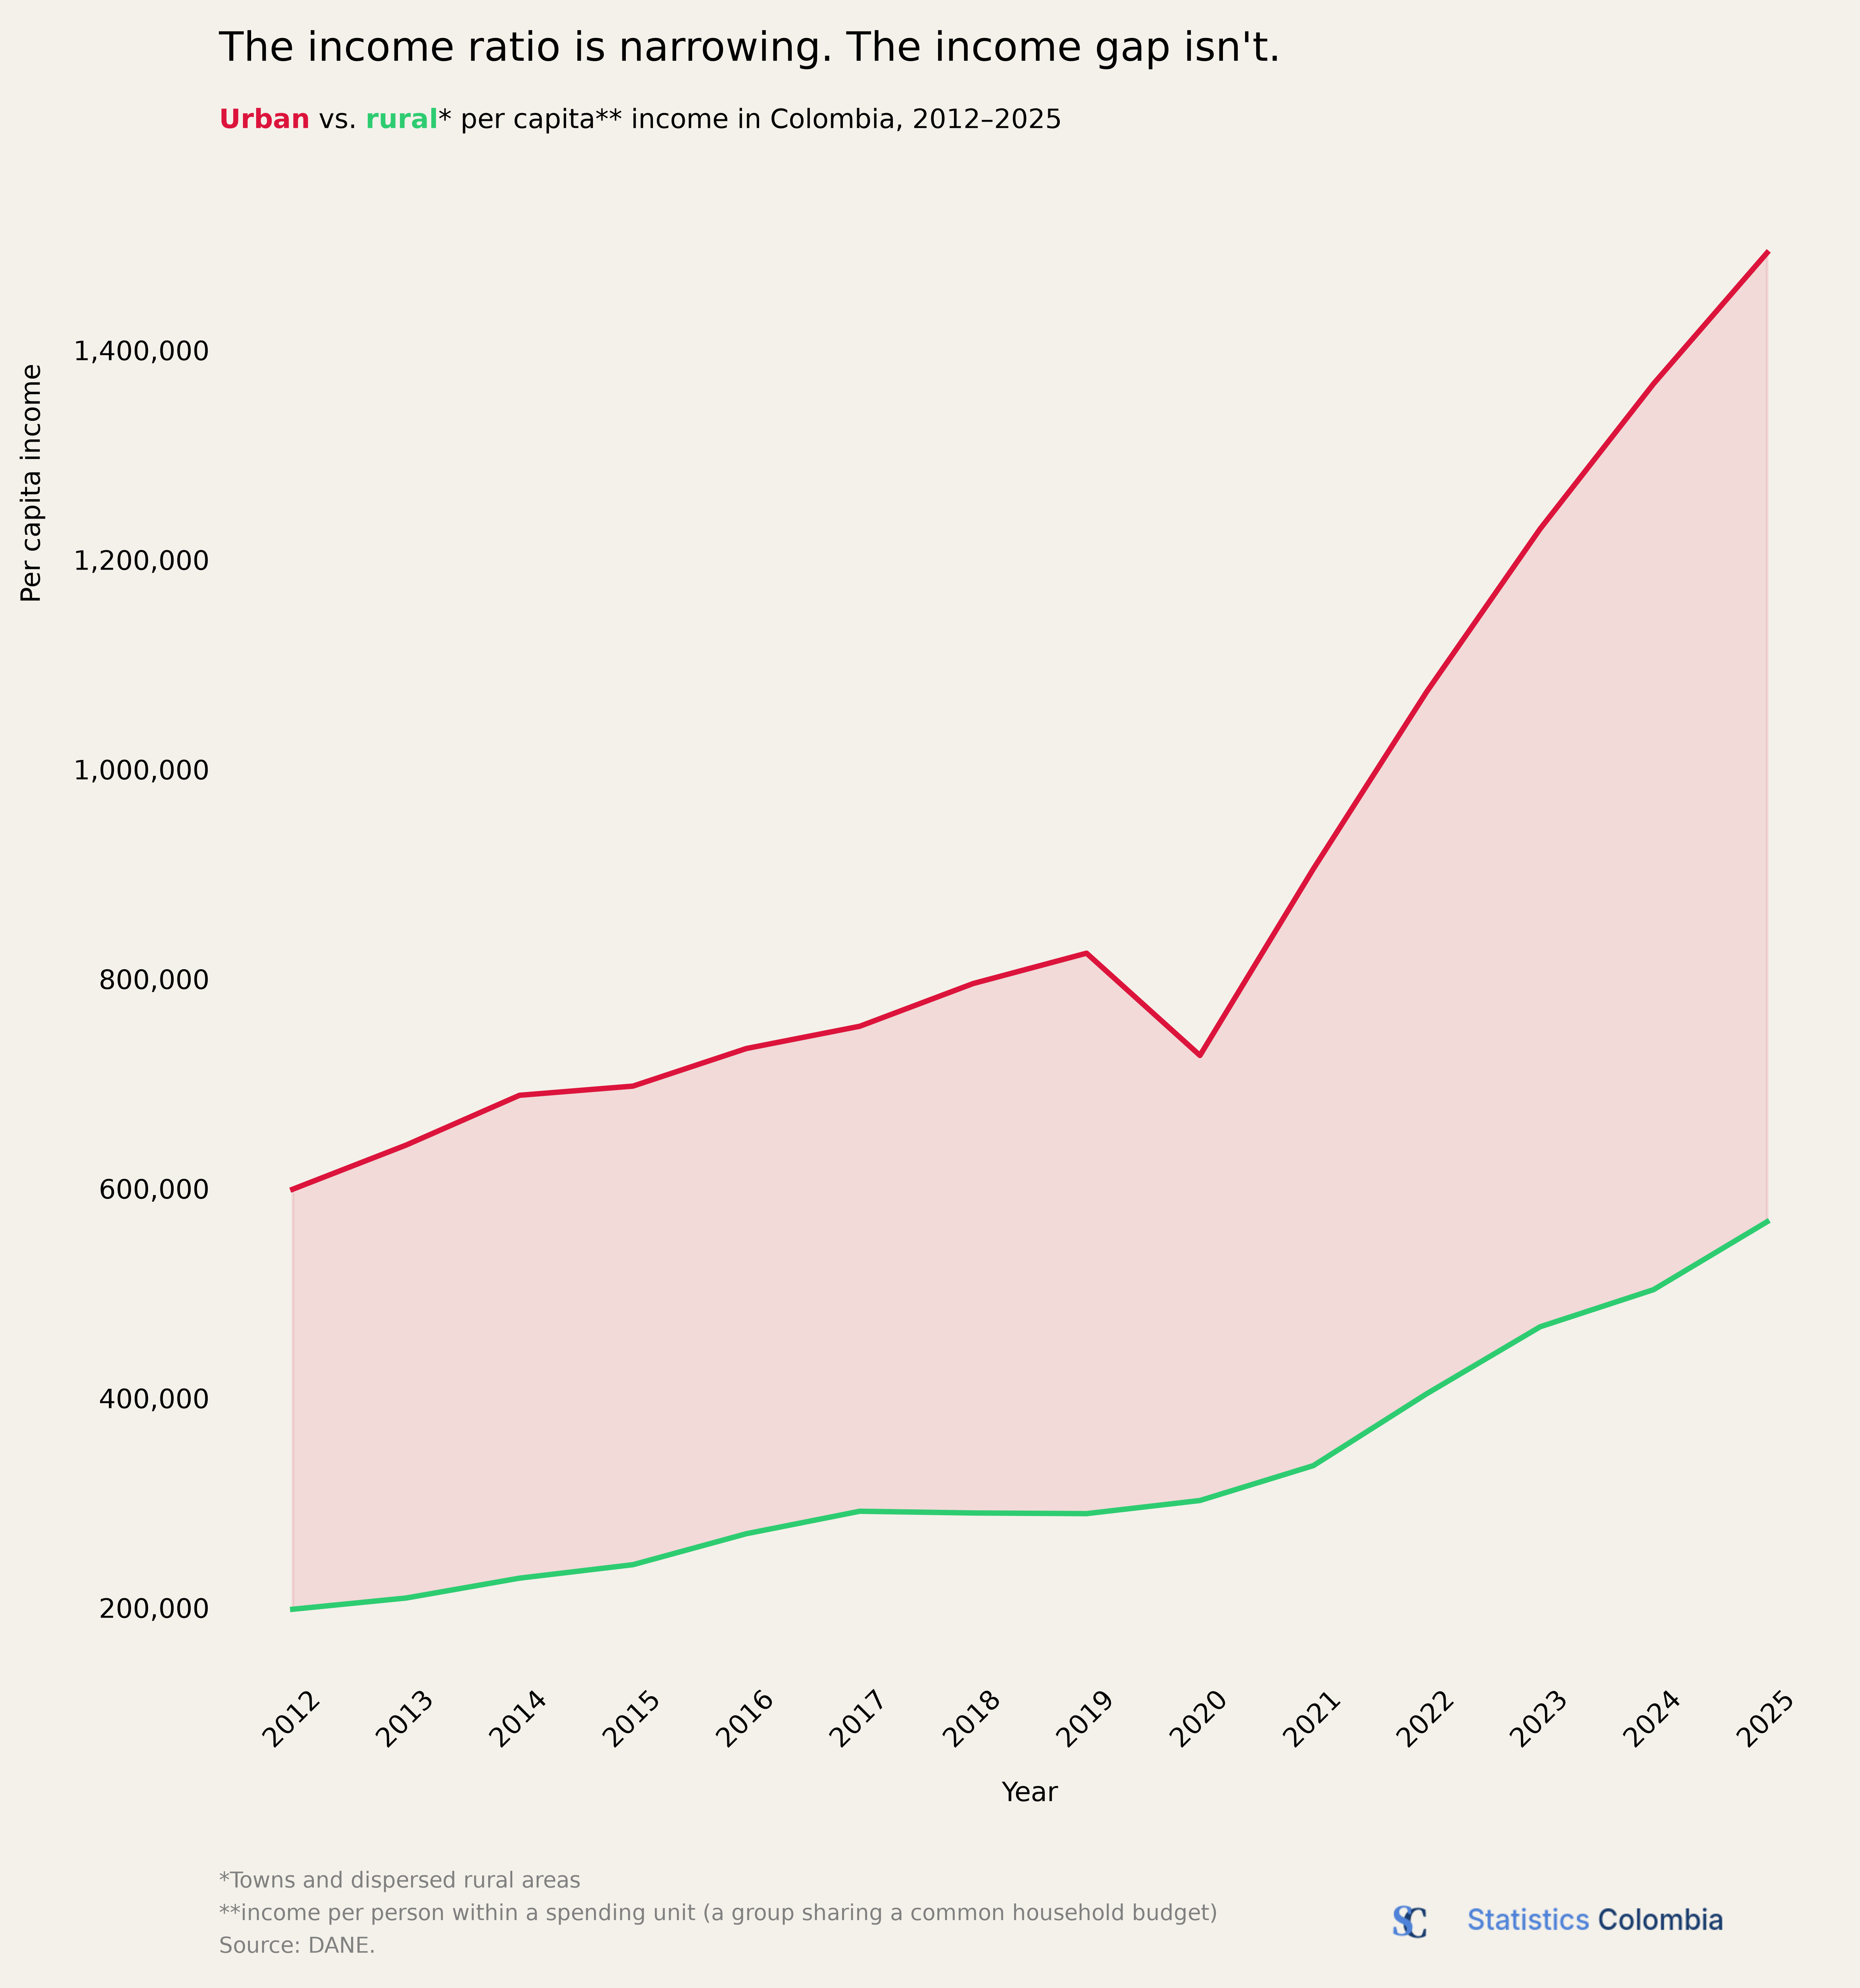

In [66]:
red = "#DC143C"
green = "#2ecc71"
background = "#F4F1EA"
urban = df.set_index("Fecha")["Cabeceras"]
rural = df.set_index("Fecha")["Centros poblados y rural disperso"]

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(urban, linewidth=2, color=red)
plt.plot(rural, linewidth=2, color=green)

plt.fill_between(urban.index, urban, rural, color=red, alpha=0.1)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.ylabel("Per capita income", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.xticks(urban.index, rotation=45)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

fig_text(
    x=0.125, y=0.96,
    s="The income ratio is narrowing. The income gap isn't.",
    fontsize=15
)

fig_text(
    x=0.125, y=0.92,
    s="<Urban> vs. <rural>* per capita** income in Colombia, 2012–2025",
    highlight_textprops=[
        {"color": red, "weight": "bold"},
        {"color": green, "weight": "bold"}
    ],
    fontsize=10
)

fig_text(
    0.125, 0.01, 
    "*Towns and dispersed rural areas\n"
    "**income per person within a spending unit (a group sharing a common household budget)\n"
    "Source: DANE.", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.75, 0.035), xycoords="figure fraction",
                    frameon=False, pad=0)
                    
plt.gca().add_artist(ab)

plt.show()